# Modelo de alfabetização municipal

Regressão de `taxa_realizada` (município-ano) a partir da base preparada.
Um modelo responde risco (ranking por ŷ) e meta (ŷ < meta). Padrões via clustering hierárquico (Ward).

## 1. Preparação dos dados

In [1]:
AMBIENTE_COLAB = False

if AMBIENTE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    silhouette_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TOP_N = 20
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

if AMBIENTE_COLAB:
    ARQUIVO = Path(
        '/content/drive/MyDrive/notebooks/dados_modelagem_municipio_ano_2024_2025.parquet'
    )
else:
    # Aceita kernel na raiz do repo ou em notebooks/
    candidatos = [
        Path('data/processed/modelagem/dados_modelagem_municipio_ano_2024_2025.parquet'),
        Path('../data/processed/modelagem/dados_modelagem_municipio_ano_2024_2025.parquet'),
    ]
    ARQUIVO = next((c.resolve() for c in candidatos if c.exists()), candidatos[0])

if not ARQUIVO.exists():
    raise FileNotFoundError(f'Arquivo não encontrado: {ARQUIVO}')

dados = pd.read_parquet(ARQUIVO)
print(dados.shape)
dados.head()

(11073, 50)


/home/mburger/study/postech/techchallenge3/postech-challenge-3/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,ano,id_uf,id_municipio,nome_municipio,alunos,taxa_realizada,proficiencia_media,escolas,pct_rede_municipal,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano,ctx_atu_fundamental_3_ano,ctx_atu_fundamental_4_ano,ctx_atu_fundamental_5_ano,ctx_atlas_idhm_longevidade,ctx_atlas_taxa_analfabetismo_11a14,ctx_atlas_taxa_analfabetismo_15a17,ctx_atlas_taxa_analfabetismo_15mais,ctx_atlas_taxa_frequencia_0a3,ctx_atlas_expectativa_anos_estudo,ctx_atlas_indice_gini,ctx_atlas_taxa_trabalho_infantil_10a14,ctx_atlas_taxa_maes_10a14,ctx_atlas_taxa_maes_chefes_familia,ctx_atlas_taxa_fora_escola_4a5,ctx_atlas_taxa_fora_escola_6a14,ctx_atlas_taxa_frequencia_liquida_fundamental,ctx_atlas_percentual_domicilios_agua,ctx_atlas_percentual_domicilios_energia,ctx_atlas_taxa_densidade_domiciliar,ctx_fundeb_nse_uf,populacao,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_media,taxa_lag1,proficiencia_lag1,participacao_lag1,meta,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,risco_educacional,risco_nao_atingir_meta,distancia_ate_a_meta,esforco_pactuado
0,2024,11,1100015,Alta Floresta D'Oeste,275,68.000,752.593,8,100.000,18.800,14.800,20.900,22.100,23.400,21.300,23.400,21.000,20.600,0.763,1.220,1.520,11.990,4.890,8.670,0.580,9.080,0.000,14.510,60.820,4.320,92.880,93.690,93.980,22.580,49.335,"22,853.000","7,067.127",0.397,0.005,"1,210.600",64.550,758.330,89.370,67.000,759.436,88.100,0.000,0.000,1.000,2.450
1,2024,11,1100023,Ariquemes,1066,65.854,748.307,18,100.000,23.500,20.500,25.200,25.000,24.900,23.200,25.800,26.000,25.500,0.806,1.550,1.090,7.900,9.890,9.180,0.530,7.890,0.000,18.070,44.660,2.790,91.310,98.540,98.580,27.150,49.335,"108,573.000","4,426.571",0.133,0.020,"1,458.570",62.300,757.100,89.790,65.000,759.436,88.100,0.000,0.000,0.854,2.700
2,2024,11,1100031,Cabixi,75,76.000,759.857,2,100.000,19.400,36.500,15.600,14.300,13.400,14.000,17.400,14.800,12.200,0.757,0.620,1.060,13.630,12.490,10.090,0.510,12.160,1.120,7.030,33.080,1.970,92.810,95.490,96.360,19.930,49.335,"5,690.000","1,314.352",0.468,0.016,"1,323.790",69.100,767.876,90.480,71.000,759.436,88.100,0.000,0.000,5.000,1.900
3,2024,11,1100049,Cacoal,951,66.351,747.937,19,83.701,17.400,17.700,17.300,20.721,21.593,22.260,21.662,17.402,19.280,0.821,1.010,0.800,8.290,11.380,9.740,0.570,11.800,0.680,12.800,37.590,2.390,93.020,97.960,98.890,20.500,49.335,"97,637.000","3,793.000",0.172,0.672,"1,625.880",62.510,755.564,84.440,65.000,759.436,88.100,0.000,0.000,1.351,2.490
4,2024,11,1100056,Cerejeiras,244,66.803,749.646,4,100.000,17.700,14.800,19.900,22.400,22.800,24.000,21.600,22.100,21.000,0.799,1.140,0.750,10.290,13.450,10.220,0.500,10.500,0.000,25.880,38.730,1.460,93.470,97.530,98.850,16.660,49.335,"16,975.000","2,783.300",0.112,0.580,"1,554.330",58.530,746.463,92.120,62.000,759.436,88.100,0.000,0.000,4.803,3.470


In [3]:
COLUNAS_CHAVE = ['ano', 'id_uf', 'id_municipio', 'nome_municipio']
ALVO = 'taxa_realizada'

COLUNAS_PROIBIDAS_X = {
    ALVO,
    'proficiencia_media',
    'risco_educacional',
    'risco_nao_atingir_meta',
    'distancia_ate_a_meta',
    'alunos',
    'escolas',
    'pct_rede_municipal',
    'meta',
    'esforco_pactuado',
    *COLUNAS_CHAVE,
}

FEATURES = [c for c in dados.columns if c not in COLUNAS_PROIBIDAS_X]

anos = sorted(dados['ano'].dropna().unique().tolist())
assert anos == [2024, 2025], anos
assert not dados.duplicated(subset=['id_municipio', 'ano']).any()

dev = dados.loc[dados['ano'].eq(2024)].copy()
teste = dados.loc[dados['ano'].eq(2025)].copy()

X_dev = dev[FEATURES].apply(pd.to_numeric, errors='coerce')
y_dev = dev[ALVO].astype(float)
groups_dev = dev['id_uf']

X_teste = teste[FEATURES].apply(pd.to_numeric, errors='coerce')
y_teste = teste[ALVO].astype(float)

print(f'Features: {len(FEATURES)}')
print(f'Dev 2024: {len(dev):,} | Teste 2025: {len(teste):,}')
print('Features:', FEATURES)

Features: 36
Dev 2024: 5,517 | Teste 2025: 5,556
Features: ['ctx_atu_educacao_infantil', 'ctx_atu_creche', 'ctx_atu_pre_escola', 'ctx_atu_fundamental_anos_iniciais', 'ctx_atu_fundamental_1_ano', 'ctx_atu_fundamental_2_ano', 'ctx_atu_fundamental_3_ano', 'ctx_atu_fundamental_4_ano', 'ctx_atu_fundamental_5_ano', 'ctx_atlas_idhm_longevidade', 'ctx_atlas_taxa_analfabetismo_11a14', 'ctx_atlas_taxa_analfabetismo_15a17', 'ctx_atlas_taxa_analfabetismo_15mais', 'ctx_atlas_taxa_frequencia_0a3', 'ctx_atlas_expectativa_anos_estudo', 'ctx_atlas_indice_gini', 'ctx_atlas_taxa_trabalho_infantil_10a14', 'ctx_atlas_taxa_maes_10a14', 'ctx_atlas_taxa_maes_chefes_familia', 'ctx_atlas_taxa_fora_escola_4a5', 'ctx_atlas_taxa_fora_escola_6a14', 'ctx_atlas_taxa_frequencia_liquida_fundamental', 'ctx_atlas_percentual_domicilios_agua', 'ctx_atlas_percentual_domicilios_energia', 'ctx_atlas_taxa_densidade_domiciliar', 'ctx_fundeb_nse_uf', 'populacao', 'ctx_ibge_area_km2', 'ctx_ibge_pct_populacao_rural', 'ctx_ibge_pct

## 2. Regressão

Baseline (`taxa_lag1`), Random Forest e HistGradientBoosting.
CV com `GroupKFold` por `id_uf`.

In [4]:
def mae_rmse_r2(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }


class BaselineTaxaLag1(BaseEstimator, RegressorMixin):
    """Prediz taxa_lag1; se nulo, usa a média de y do treino."""

    def __init__(self, col='taxa_lag1'):
        self.col = col

    def fit(self, X, y):
        self.media_treino_ = float(np.nanmean(np.asarray(y, dtype=float)))
        self.n_features_in_ = X.shape[1]
        return self

    def predict(self, X):
        pred = pd.to_numeric(X[self.col], errors='coerce').to_numpy(dtype=float)
        return np.where(np.isnan(pred), self.media_treino_, pred)


pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=2,
        random_state=RANDOM_STATE,
    )),
])

pipe_hgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=200,
        random_state=RANDOM_STATE,
    )),
])

modelos = {
    'Baseline taxa_lag1': BaselineTaxaLag1(),
    'Random Forest': pipe_rf,
    'HistGradientBoosting': pipe_hgb,
}

cv = GroupKFold(n_splits=5)
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2',
}

linhas = []
for nome, modelo in modelos.items():
    cv_res = cross_validate(
        modelo,
        X_dev,
        y_dev,
        groups=groups_dev,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )
    linhas.append({
        'modelo': nome,
        'MAE_CV': -cv_res['test_MAE'].mean(),
        'RMSE_CV': -cv_res['test_RMSE'].mean(),
        'R2_CV': cv_res['test_R2'].mean(),
    })

resumo_cv = pd.DataFrame(linhas).sort_values('MAE_CV')
display(resumo_cv)

vencedor = resumo_cv.iloc[0]['modelo']
mae_cv_default = float(resumo_cv.iloc[0]['MAE_CV'])
print(f'Modelo escolhido (menor MAE_CV): {vencedor}')
print(f'MAE_CV default: {mae_cv_default:.3f}')

,modelo,MAE_CV,RMSE_CV,R2_CV
2,HistGradientBoosting,10.669,13.593,0.439
1,Random Forest,10.751,13.640,0.438
0,Baseline taxa_lag1,12.570,16.640,0.140


Modelo escolhido (menor MAE_CV): HistGradientBoosting
MAE_CV default: 10.669


### 2.1 Otimização do vencedor

`RandomizedSearchCV` apenas no modelo escolhido na comparação direta. Mesmo `GroupKFold` por `id_uf`. O ano 2025 não entra na busca.

In [5]:
PARAM_DISTRIBUTIONS = {
    'HistGradientBoosting': {
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth': [4, 6, 8],
        'model__max_iter': [150, 200, 400],
        'model__min_samples_leaf': [10, 20, 50],
        'model__l2_regularization': [0.0, 0.1, 1.0],
    },
    'Random Forest': {
        'model__n_estimators': [200, 300, 400],
        'model__max_depth': [8, 12, 16, None],
        'model__min_samples_leaf': [2, 5, 10],
        'model__max_features': [0.5, 'sqrt', 1.0],
    },
}

N_ITER_SEARCH = 20
param_dist = PARAM_DISTRIBUTIONS.get(vencedor)

if param_dist is None:
    print(f'Sem grade para "{vencedor}"; usando hiperparâmetros default.')
    modelo_final = clone(modelos[vencedor]).fit(X_dev, y_dev)
    mae_cv_tunado = mae_cv_default
    best_params = {}
else:
    search = RandomizedSearchCV(
        estimator=clone(modelos[vencedor]),
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        scoring='neg_mean_absolute_error',
        cv=GroupKFold(n_splits=5),
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_dev, y_dev, groups=groups_dev)
    modelo_final = search.best_estimator_
    mae_cv_tunado = float(-search.best_score_)
    best_params = search.best_params_
    print('Melhores hiperparâmetros:')
    display(pd.Series(best_params, name='valor').to_frame())

comparacao_cv = pd.DataFrame([
    {'etapa': 'default', 'modelo': vencedor, 'MAE_CV': mae_cv_default},
    {'etapa': 'RandomizedSearch', 'modelo': vencedor, 'MAE_CV': mae_cv_tunado},
])
display(comparacao_cv)
print(
    f'Delta MAE_CV (tunado - default): {mae_cv_tunado - mae_cv_default:+.3f}'
)

Melhores hiperparâmetros:


,valor
model__min_samples_leaf,50.000
model__max_iter,200.000
model__max_depth,4.000
model__learning_rate,0.050
model__l2_regularization,0.100


,etapa,modelo,MAE_CV
0,default,HistGradientBoosting,10.669
1,RandomizedSearch,HistGradientBoosting,10.583


Delta MAE_CV (tunado - default): -0.086


## 3. Avaliação

Modelo pós-RandomizedSearch (ou default, se a busca foi pulada). Métricas no teste temporal 2025.

In [6]:
yhat_teste = np.clip(modelo_final.predict(X_teste), 0, 100)
metricas_teste = mae_rmse_r2(y_teste, yhat_teste)

# Baseline no teste para referência
base = BaselineTaxaLag1().fit(X_dev, y_dev)
yhat_base = np.clip(base.predict(X_teste), 0, 100)
metricas_base = mae_rmse_r2(y_teste, yhat_base)

comparacao_teste = pd.DataFrame([
    {'modelo': 'Baseline taxa_lag1', **metricas_base},
    {'modelo': f'{vencedor} (tunado)', **metricas_teste},
])
display(comparacao_teste)

# OOF 2024 do modelo final (GroupKFold)
yhat_oof = np.clip(
    cross_val_predict(
        clone(modelo_final),
        X_dev,
        y_dev,
        groups=groups_dev,
        cv=GroupKFold(n_splits=5),
        n_jobs=1,
    ),
    0,
    100,
)
print(f'OOF 2024 MAE: {mean_absolute_error(y_dev, yhat_oof):.3f}')

resultado_teste = teste[COLUNAS_CHAVE + [ALVO, 'meta']].copy()
resultado_teste['yhat'] = yhat_teste
resultado_teste['erro'] = resultado_teste[ALVO] - resultado_teste['yhat']
resultado_teste.head()


,modelo,MAE,RMSE,R2
0,Baseline taxa_lag1,13.164,17.173,-0.175
1,HistGradientBoosting (tunado),10.162,12.928,0.334


OOF 2024 MAE: 10.581


,ano,id_uf,id_municipio,nome_municipio,taxa_realizada,meta,yhat,erro
5517,2025,11,1100015,Alta Floresta D'Oeste,78.148,70.000,60.555,17.594
5518,2025,11,1100023,Ariquemes,79.698,68.000,58.097,21.601
5519,2025,11,1100031,Cabixi,86.885,73.000,71.269,15.616
5520,2025,11,1100049,Cacoal,84.777,68.000,64.226,20.551
5521,2025,11,1100056,Cerejeiras,89.796,66.000,65.476,24.320


## 4. Fatores e influência no modelo

`permutation_importance` e SHAP (`TreeExplainer`, material aula 3) no holdout 2025. Associação preditiva, não causalidade.

,feature,importance_mean,importance_std
32,proficiencia_lag1,1.520,0.070
31,taxa_lag1,0.406,0.035
33,participacao_lag1,0.248,0.016
35,ctx_inep_uf_percentual_participacao_lag1,0.215,0.023
25,ctx_fundeb_nse_uf,0.181,0.013
34,ctx_inep_uf_media_portugues_lag1,0.135,0.037
24,ctx_atlas_taxa_densidade_domiciliar,0.092,0.025
16,ctx_atlas_taxa_trabalho_infantil_10a14,0.059,0.008
5,ctx_atu_fundamental_2_ano,0.054,0.012
28,ctx_ibge_pct_populacao_rural,0.038,0.005


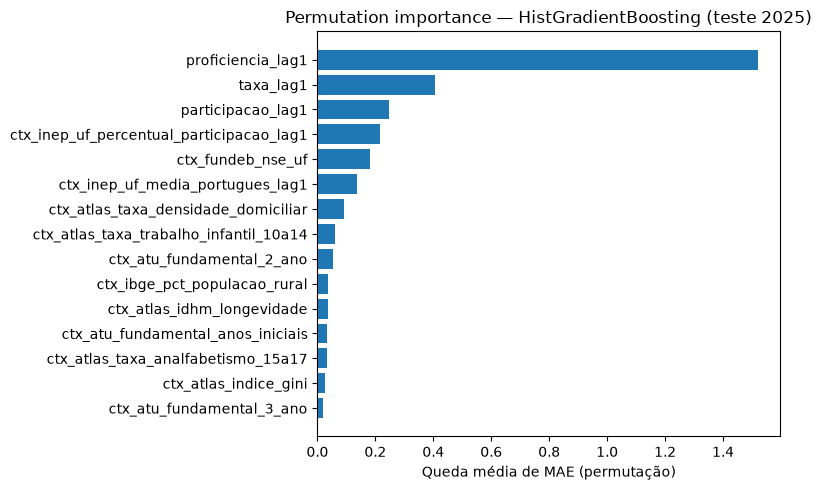

In [7]:
imp = permutation_importance(
    modelo_final,
    X_teste,
    y_teste,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='neg_mean_absolute_error',
    n_jobs=2,
)

importancia = (
    pd.DataFrame({
        'feature': FEATURES,
        'importance_mean': imp.importances_mean,
        'importance_std': imp.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
)

top15 = importancia.head(15)
display(top15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top15['feature'][::-1], top15['importance_mean'][::-1])
ax.set_xlabel('Queda média de MAE (permutação)')
ax.set_title(f'Permutation importance — {vencedor} (teste 2025)')
plt.tight_layout()
plt.show()

SHAP em 1,000 municípios do teste 2025


,feature,mean_abs_shap
32,proficiencia_lag1,6.637
34,ctx_inep_uf_media_portugues_lag1,3.985
35,ctx_inep_uf_percentual_participacao_lag1,1.636
31,taxa_lag1,1.471
33,participacao_lag1,1.359
24,ctx_atlas_taxa_densidade_domiciliar,1.270
25,ctx_fundeb_nse_uf,1.212
10,ctx_atlas_taxa_analfabetismo_11a14,1.056
5,ctx_atu_fundamental_2_ano,0.528
26,populacao,0.426


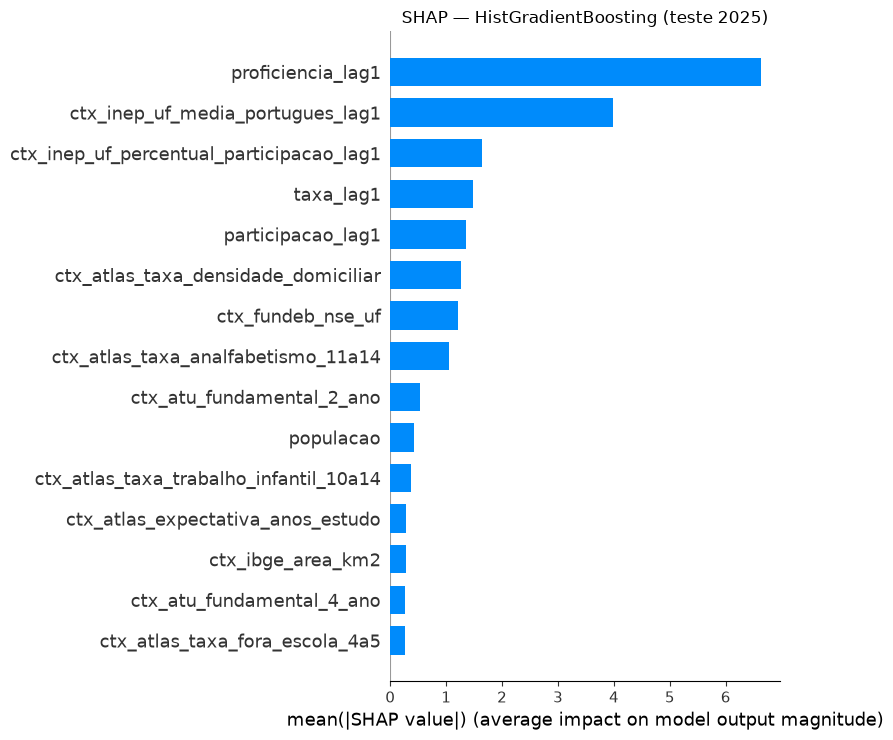

Comparação permutation × SHAP (top por melhor ranking):


,feature,rank_permutation,rank_shap,permutation_mae,mean_abs_shap
0,proficiencia_lag1,1,1,1.520,6.637
1,taxa_lag1,2,4,0.406,1.471
5,ctx_inep_uf_media_portugues_lag1,6,2,0.135,3.985
2,participacao_lag1,3,5,0.248,1.359
3,ctx_inep_uf_percentual_participacao_lag1,4,3,0.215,1.636
4,ctx_fundeb_nse_uf,5,7,0.181,1.212
6,ctx_atlas_taxa_densidade_domiciliar,7,6,0.092,1.270
7,ctx_atlas_taxa_trabalho_infantil_10a14,8,11,0.059,0.369
35,ctx_atlas_taxa_analfabetismo_11a14,36,8,-0.105,1.056
8,ctx_atu_fundamental_2_ano,9,9,0.054,0.528


In [8]:
# SHAP global — padrão do material (TreeExplainer + média |SHAP| + bar plot)
modelo_arvore = modelo_final.named_steps['model']
X_teste_imp = pd.DataFrame(
    modelo_final.named_steps['imputer'].transform(X_teste),
    columns=FEATURES,
    index=X_teste.index,
)

n_shap = min(1000, len(X_teste_imp))
X_shap = X_teste_imp.sample(n=n_shap, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(modelo_arvore)
shap_values = explainer.shap_values(X_shap)

# Classificadores RF podem devolver lista; regressão retorna array 2D
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_rank = (
    pd.DataFrame({
        'feature': FEATURES,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    })
    .sort_values('mean_abs_shap', ascending=False)
)

print(f'SHAP em {n_shap:,} municípios do teste 2025')
display(shap_rank.head(15))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.title(f'SHAP — {vencedor} (teste 2025)')
plt.tight_layout()
plt.show()

# Concordância com permutation importance
comparacao_importancia = (
    importancia.loc[:, ['feature', 'importance_mean']]
    .rename(columns={'importance_mean': 'permutation_mae'})
    .merge(
        shap_rank.loc[:, ['feature', 'mean_abs_shap']],
        on='feature',
        how='inner',
    )
)
comparacao_importancia['rank_permutation'] = (
    comparacao_importancia['permutation_mae'].rank(ascending=False).astype(int)
)
comparacao_importancia['rank_shap'] = (
    comparacao_importancia['mean_abs_shap'].rank(ascending=False).astype(int)
)
top_comp = (
    comparacao_importancia
    .assign(rank_min=lambda d: d[['rank_permutation', 'rank_shap']].min(axis=1))
    .sort_values('rank_min')
    .head(15)
    .loc[:, ['feature', 'rank_permutation', 'rank_shap', 'permutation_mae', 'mean_abs_shap']]
)
print('Comparação permutation × SHAP (top por melhor ranking):')
display(top_comp)


## 5. Avaliação dos municípios

### 5.1 Maior risco educacional

Ranking por ŷ crescente em 2025 (priorização; sem corte absoluto).

In [9]:
ranking_risco = (
    resultado_teste
    .sort_values('yhat', ascending=True)
    .loc[:, COLUNAS_CHAVE + ['yhat', ALVO]]
    .head(TOP_N)
    .reset_index(drop=True)
)
ranking_risco.index = ranking_risco.index + 1
display(ranking_risco)

print('Municípios com menor ŷ por UF (contagem no top 100):')
display(
    resultado_teste
    .nsmallest(100, 'yhat')
    .groupby('id_uf')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .to_frame('n_top100_risco')
)

,ano,id_uf,id_municipio,nome_municipio,yhat,taxa_realizada
1,2025,28,2805604,Porto da Folha,27.778,32.975
2,2025,28,2802700,Ilha das Flores,28.120,55.738
3,2025,28,2801504,Carmópolis,29.425,37.762
4,2025,28,2805406,Poço Redondo,29.660,26.722
5,2025,28,2806305,Santa Luzia do Itanhy,29.856,42.328
6,2025,28,2804904,Pacatuba,29.981,50.286
7,2025,28,2803609,Laranjeiras,31.177,33.043
8,2025,15,1505205,Oeiras do Pará,31.338,35.404
9,2025,28,2800605,Barra dos Coqueiros,31.862,49.841
10,2025,28,2804300,Muribeca,31.981,64.815


Municípios com menor ŷ por UF (contagem no top 100):


,n_top100_risco
id_uf,
28,38
24,18
15,17
29,16
13,9
43,2


### 5.2 Risco de não atingir a meta

Pós-processamento da mesma ŷ: flag `yhat < meta` (não é classificador dedicado).

In [10]:
meta_avaliacao = resultado_teste.dropna(subset=['meta']).copy()
meta_avaliacao['risco_meta_pred'] = (
    meta_avaliacao['yhat'] < meta_avaliacao['meta']
).astype(int)
meta_avaliacao['risco_meta_obs'] = (
    meta_avaliacao[ALVO] < meta_avaliacao['meta']
).astype(int)

print(
    f"Previstos abaixo da meta: {meta_avaliacao['risco_meta_pred'].mean():.1%} "
    f"({meta_avaliacao['risco_meta_pred'].sum():,} / {len(meta_avaliacao):,})"
)
print(
    f"Observados abaixo da meta: {meta_avaliacao['risco_meta_obs'].mean():.1%}"
)

# Acurácia da regra yhat < meta vs verdade 2025 (só referência)
print('Referência da regra no teste 2025:')
print('  accuracy :', f"{accuracy_score(meta_avaliacao['risco_meta_obs'], meta_avaliacao['risco_meta_pred']):.3f}")
print('  precision:', f"{precision_score(meta_avaliacao['risco_meta_obs'], meta_avaliacao['risco_meta_pred']):.3f}")
print('  recall   :', f"{recall_score(meta_avaliacao['risco_meta_obs'], meta_avaliacao['risco_meta_pred']):.3f}")

ranking_meta = (
    meta_avaliacao
    .loc[meta_avaliacao['risco_meta_pred'].eq(1)]
    .assign(gap_pred=lambda d: d['meta'] - d['yhat'])
    .sort_values('gap_pred', ascending=False)
    .loc[:, COLUNAS_CHAVE + ['yhat', 'meta', ALVO, 'gap_pred']]
    .head(TOP_N)
    .reset_index(drop=True)
)
ranking_meta.index = ranking_meta.index + 1
display(ranking_meta)

display(
    meta_avaliacao
    .loc[meta_avaliacao['risco_meta_pred'].eq(1)]
    .groupby('id_uf')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .to_frame('n_risco_meta_pred')
)

Previstos abaixo da meta: 46.1% (2,537 / 5,499)
Observados abaixo da meta: 27.3%
Referência da regra no teste 2025:
  accuracy : 0.672
  precision: 0.440
  recall   : 0.744


,ano,id_uf,id_municipio,nome_municipio,yhat,meta,taxa_realizada,gap_pred
1,2025,43,4301073,Arroio do Padre,35.352,80.000,57.895,44.648
2,2025,43,4310553,Itacurubi,43.082,80.000,20.000,36.918
3,2025,43,4313953,Pantano Grande,38.241,75.000,55.085,36.759
4,2025,21,2108801,Pirapemas,44.070,80.000,73.881,35.930
5,2025,43,4304408,Canela,43.314,79.000,54.247,35.686
6,2025,43,4306700,Dona Francisca,44.658,80.000,68.182,35.342
7,2025,43,4305900,Coronel Bicaco,44.639,79.000,67.308,34.361
8,2025,21,2100808,Anapurus,46.109,80.000,41.753,33.891
9,2025,43,4314209,Pedro Osório,38.434,72.000,40.385,33.566
10,2025,21,2106359,Marajá do Sena,46.847,80.000,73.333,33.153


,n_risco_meta_pred
id_uf,
43,444
35,334
29,296
41,270
15,132
21,129
26,121
31,119
33,89


## 6. Regiões com padrões semelhantes (hierárquico)

Imputer + StandardScaler + Ward (como no material). PCA(2) só para visualização. Dendrograma em amostra; `K` por silhouette (`K = 2…8`).

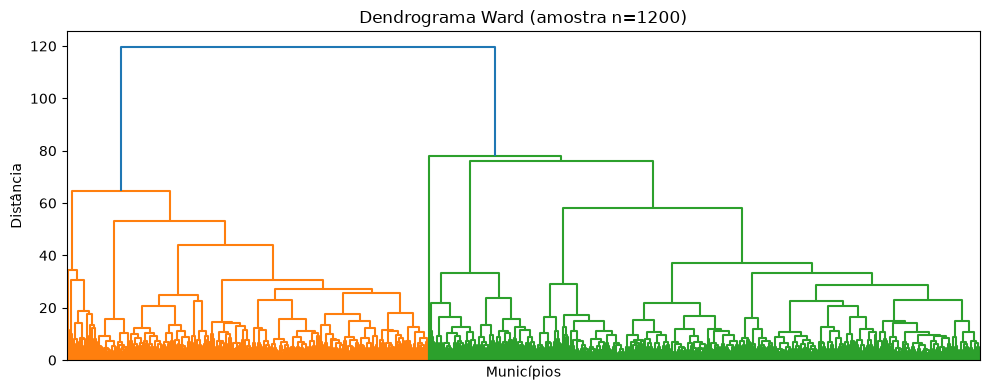

,K,silhouette
0,2,0.184
1,3,0.095
2,4,0.101
3,5,0.085
4,6,0.091
5,7,0.078
6,8,0.081


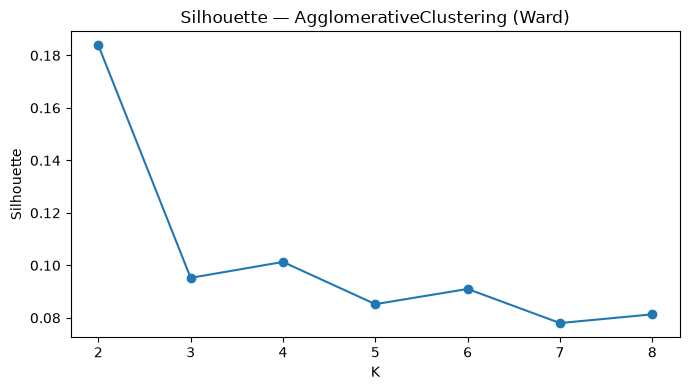

K escolhido: 2 (silhouette=0.184)
Silhouette baixa (< 0,25): a separação entre grupos é fraca; os clusters seguem para interpretação exploratória.


,n,pct
0,3413,0.614
1,2143,0.386


Clusters: 2


In [11]:
X_cluster = X_teste.copy()

prep_cluster = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
X_scaled = prep_cluster.fit_transform(X_cluster)

# Dendrograma em amostra (material do curso; amostra para legibilidade)
N_DENDRO = min(1200, len(X_scaled))
rng = np.random.RandomState(RANDOM_STATE)
idx_dendro = rng.choice(len(X_scaled), size=N_DENDRO, replace=False)
Z = linkage(X_scaled[idx_dendro], method='ward')

fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title(f'Dendrograma Ward (amostra n={N_DENDRO})')
ax.set_xlabel('Municípios')
ax.set_ylabel('Distância')
plt.tight_layout()
plt.show()

# Escolha de K por silhouette no espaço escalado
linhas_k = []
for k in range(2, 9):
    labels_k = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_k)
    linhas_k.append({'K': k, 'silhouette': sil})

sil_tab = pd.DataFrame(linhas_k)
display(sil_tab)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sil_tab['K'], sil_tab['silhouette'], marker='o')
ax.set_xlabel('K')
ax.set_ylabel('Silhouette')
ax.set_title('Silhouette — AgglomerativeClustering (Ward)')
plt.tight_layout()
plt.show()

K_otimo = int(sil_tab.loc[sil_tab['silhouette'].idxmax(), 'K'])
sil_max = float(sil_tab['silhouette'].max())
print(f'K escolhido: {K_otimo} (silhouette={sil_max:.3f})')
if sil_max < 0.25:
    print(
        'Silhouette baixa (< 0,25): a separação entre grupos é fraca; '
        'os clusters seguem para interpretação exploratória.'
    )

labels = AgglomerativeClustering(
    n_clusters=K_otimo,
    linkage='ward',
).fit_predict(X_scaled)

cluster_resumo = (
    pd.Series(labels)
    .value_counts()
    .sort_index()
    .rename('n')
    .to_frame()
)
cluster_resumo['pct'] = cluster_resumo['n'] / len(labels)
display(cluster_resumo)
print(f'Clusters: {K_otimo}')


,yhat,taxa_realizada,proficiencia_lag1,taxa_lag1,participacao_lag1,ctx_inep_uf_percentual_participacao_lag1,ctx_fundeb_nse_uf,ctx_inep_uf_media_portugues_lag1,ctx_atlas_taxa_densidade_domiciliar,ctx_atlas_taxa_trabalho_infantil_10a14,n
cluster,,,,,,,,,,,
0,70.025,74.633,756.406,67.862,90.224,86.155,54.691,750.418,18.391,10.477,3413
1,60.253,68.227,747.269,54.874,92.300,89.846,43.058,744.305,35.943,10.861,2143



Cluster 0 — top UFs:


,n
id_uf,
31,832
35,644
43,487
41,398
42,294



Cluster 1 — top UFs:


,n
id_uf,
29,408
22,220
21,212
25,203
23,183


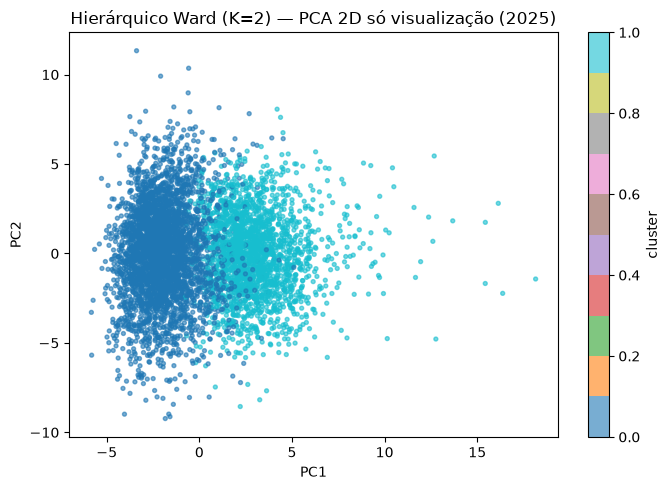

In [12]:
perfil = teste[COLUNAS_CHAVE].copy()
perfil['cluster'] = labels
perfil['yhat'] = yhat_teste
perfil[ALVO] = y_teste.to_numpy()

# Features mais importantes para descrever os clusters
top_feats = importancia['feature'].head(8).tolist()
perfil_feats = X_teste[top_feats].copy()
perfil_feats.columns = top_feats

resumo_cluster = (
    pd.concat([perfil[['cluster', 'yhat', ALVO]], perfil_feats], axis=1)
    .groupby('cluster')
    .mean(numeric_only=True)
)
resumo_cluster['n'] = perfil.groupby('cluster').size()
display(resumo_cluster.sort_index())

for c in sorted(perfil['cluster'].unique())[:5]:
    print(f'\nCluster {c} — top UFs:')
    display(
        perfil.loc[perfil['cluster'].eq(c)]
        .groupby('id_uf')
        .size()
        .sort_values(ascending=False)
        .head(5)
        .to_frame('n')
    )

# PCA 2D só para visualização (material do curso)
X_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=8, cmap='tab10', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Hierárquico Ward (K={K_otimo}) — PCA 2D só visualização (2025)')
plt.colorbar(sc, ax=ax, label='cluster')
plt.tight_layout()
plt.show()


## Conclusão

- Alvo único: `taxa_realizada`; comparação direta com GroupKFold (UF) em 2024.
- Vencedor refinado com `RandomizedSearchCV` (sem usar 2025) e validado no teste temporal.
- Influência: permutation importance e SHAP (`TreeExplainer`) no teste.
- Risco educacional: ranking por ŷ.
- Meta: pós-processamento `yhat < meta`.
- Padrões: clustering hierárquico (Ward) em features escaladas; PCA só na visualização.
